# Spike responses to natural images and movies

This notebook generates the plots for Figure 2. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [1]:
import os

import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from retina import analysis

import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
dark_blue = "#1f78b4"
dark_orange = "#ff7f00"

In [3]:
root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")

In [4]:
all_spike_stats = analysis.AllDatasetSpikeStats(root)

In [5]:
active_idxs = all_spike_stats.model_movie_stats.active_unit_idxs
print(f"N unresponsive units = {all_spike_stats.model_movie_stats.n_unresponsive_units}")

N unresponsive units = 113


## Spike raster

In [6]:
def plot_frame(frame, ax):
    ax.imshow(frame, vmin=-2, vmax=2, cmap="Greys")
    ax.spines["right"].set_linewidth(2)
    ax.spines["top"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

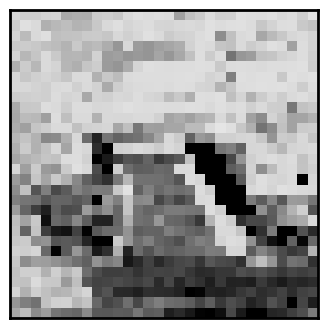

In [7]:
# Image frame
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

plot_frame(all_spike_stats.sal_img_stats.x[0, 0][0], ax)

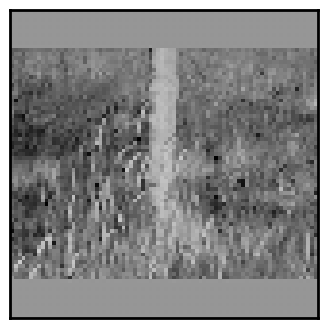

In [8]:
# Movie frame
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

plot_frame(all_spike_stats.mouse_movie_stats.x[0, 0][0], ax)

In [9]:
def plot_raster(x, y, title, x_max, x_max_v, y_max, ylabel, ax):
    ax.scatter(x, y, s=0.5, c="black")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    labelsize = 30
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_title(title, fontsize=30, pad=12)
    ax.set_xlim([0, x_max])
    ax.set_ylim([0, y_max])
    ax.set_xticks([0, x_max])
    ax.set_xticklabels([0, x_max_v])
    ax.set_yticks([0, y_max])
    ax.set_yticklabels([0, y_max])
    ax.set_ylabel(ylabel, fontsize=30, labelpad=8)

## Spike stats

In [10]:
def plot_natural_spike_stats(data_df, y_label, yticks, palette, ax):
    sns.stripplot(
        data=data_df,
        x="animal",
        y="y",
        ax=ax,
        color="black",
        size=2,
        jitter=0.25,
        alpha=0.25,     
        zorder=1
    )
    
    sns.violinplot(
        data=data_df,
        x="animal",
        y="y",
        ax=ax,
        density_norm="width",   # or scale="width" if seaborn < 0.13
        inner=None,
        linewidth=2,
        palette=palette,
        zorder=2
    )
    
    for pc in ax.collections:
        pc.set_alpha(0.7)
    
    means = data_df.groupby("animal", as_index=False)["y"].mean()
    
    sns.scatterplot(
        data=means,
        x="animal",
        y="y",
        ax=ax,
        color="black",
        marker="D",
        s=60,
        zorder=3
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs, rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=fs, labelpad=8)
    ax.set_ylim(0, yticks[-1])
    ax.set_yticks(yticks)
    
    ax.legend().set_visible(False)

In [11]:
def plot_CC(lag_list, correlation_list, label_list, colour_list, xlim, ylim, ax):
    for i in range(len(lag_list)):
        ax.plot(lag_list[i], correlation_list[i], label=label_list[i], c=colour_list[i], linewidth=4)
    ax.set_xlim([-xlim, xlim])
    ax.set_ylim([ylim[0], ylim[1]])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    ax.set_xlabel("Lag (s)", fontsize=30, labelpad=8)
    ax.set_ylabel("CC", fontsize=30, labelpad=8)

## Image stats subplot

In [12]:
lag_list, correlation_list, label_list, colour_list = all_spike_stats.get_image_CC(pairs=2000, bin_dt=24)

In [13]:
print(label_list)
print(correlation_list[1].max(), correlation_list[2].max(), correlation_list[3].max())#Luke, check this out

['Salamander', 'Prediction model', 'Pred. model (no rec.)', 'Encoding model']
0.016801420732268264 0.011949280451517552 0.09486200414331897


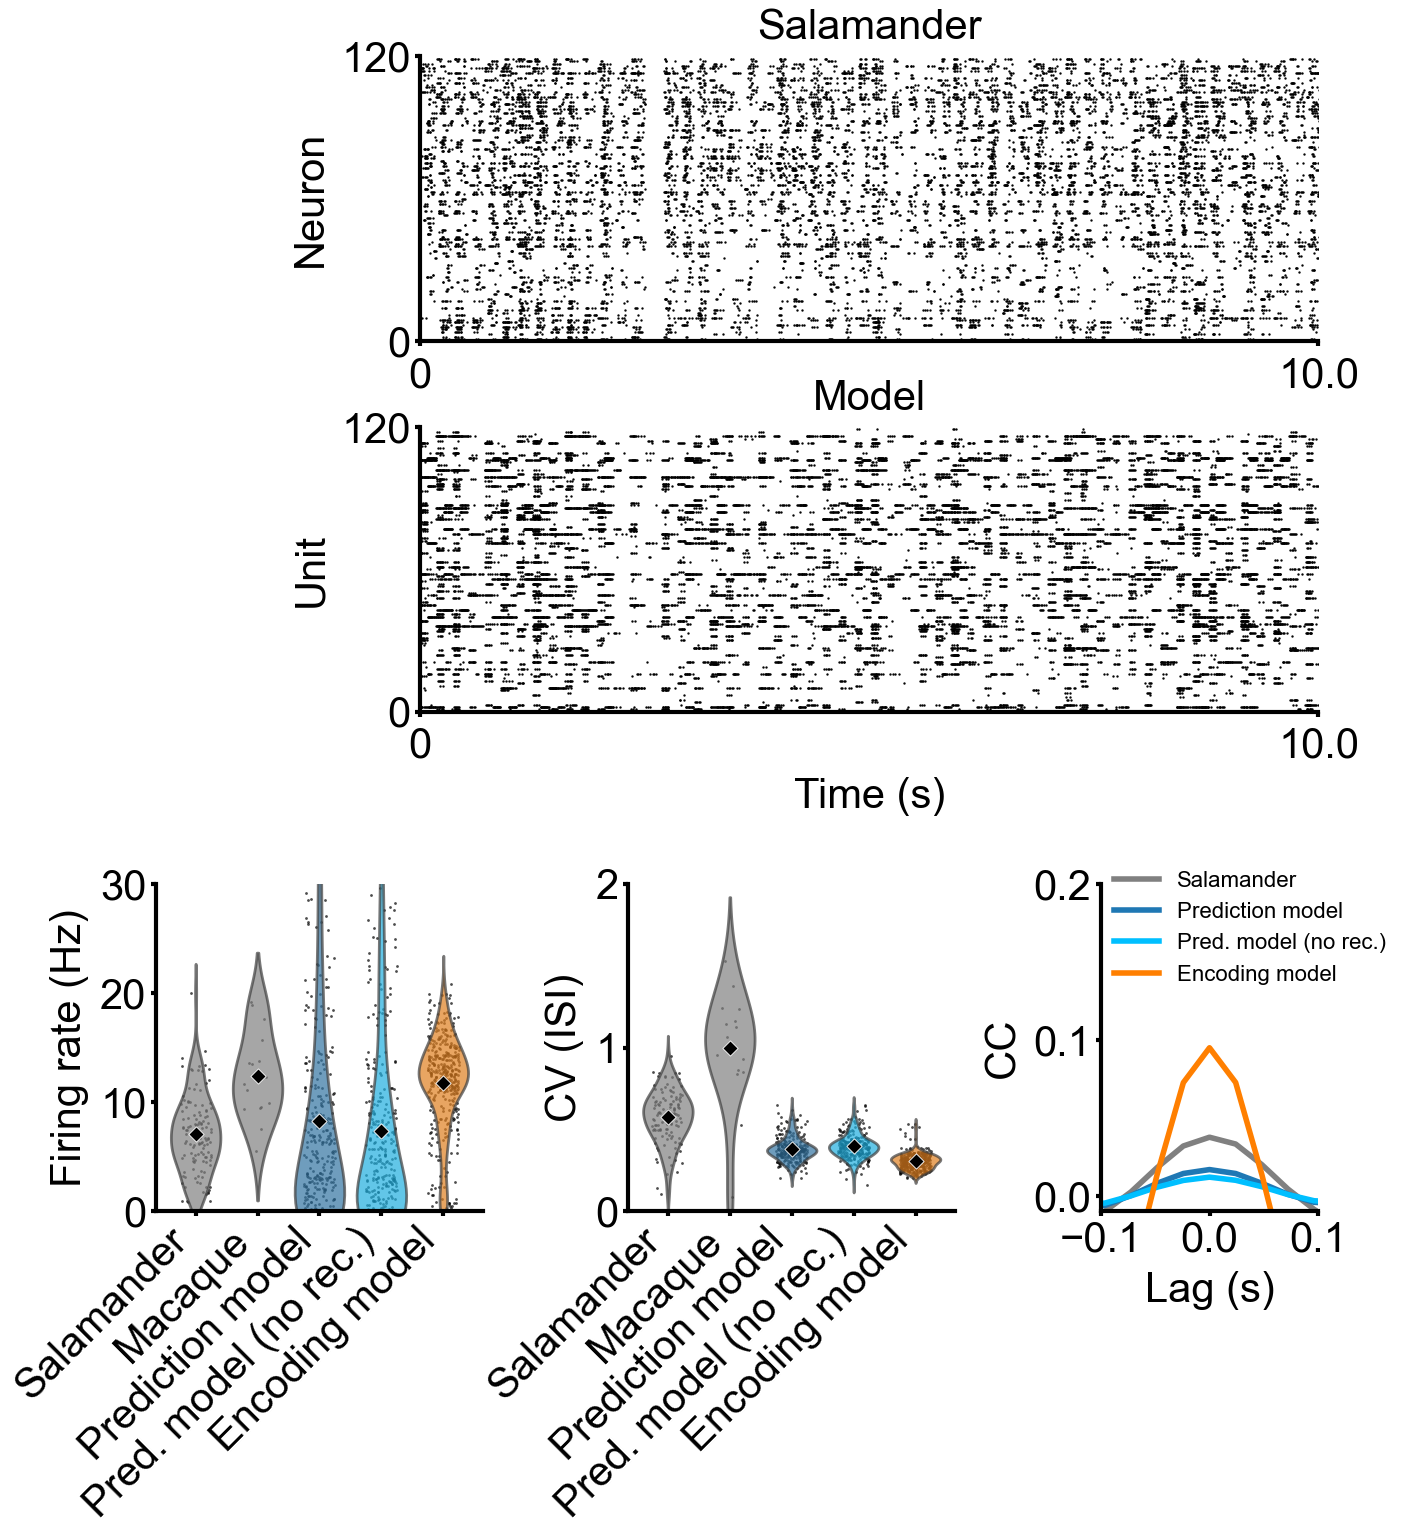

In [14]:
fig = plt.figure(figsize=(15, 15))
fig_spec = gridspec.GridSpec(2, 1, wspace=0, hspace=0.35, height_ratios=[1, 0.5])
top_spec = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[0], width_ratios=[0.25, 0.85], wspace=0)
top_spec = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=top_spec[1], height_ratios=[0.5, 0.5], hspace=0.3)
bottom_spec = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=fig_spec[1], width_ratios=[1.5, 1.5, 1], wspace=0.5)

# Top
ax = plt.Subplot(fig, top_spec[0])
plot_raster(*all_spike_stats.sal_img_stats.get_exp_spike_times(), "Salamander", 2400, "10.0", 120, "Neuron", ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, top_spec[1])
plot_raster(*all_spike_stats.sal_img_stats.get_pred_spike_times(active_idxs, 120, 42), "Model", 2400, "10.0", 120, "Unit", ax)
ax.set_xlabel("Time (s)", fontsize=30, labelpad=8)
fig.add_subplot(ax)

# Bottom
firing_rate_df = all_spike_stats.get_spike_rate_df(img=True)
cv_df = all_spike_stats.get_cv_df(img=True)

ax = plt.Subplot(fig, bottom_spec[0])
plot_natural_spike_stats(firing_rate_df, "Firing rate (Hz)", [0, 10, 20, 30], ["gray", "gray", dark_blue, "deepskyblue", dark_orange], ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, bottom_spec[1])
plot_natural_spike_stats(cv_df, "CV (ISI)", [0, 1, 2], ["gray", "gray", dark_blue, "deepskyblue", dark_orange], ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, bottom_spec[2])
plot_CC(lag_list, correlation_list, label_list, colour_list, 0.1, [-0.01, 0.2], ax)
leg = ax.legend(bbox_to_anchor=(1.4, 1.1), loc="upper right", fontsize=16, frameon=False)
ax.get_legend().set_title(None)
fig.add_subplot(ax)

plt.savefig(f"{root}/figures/fig2/image_stats.svg", format="svg", transparent=False, bbox_inches="tight")

In [15]:
model_img_firing = firing_rate_df[firing_rate_df["animal"] == "Prediction model"]["y"].values
model_img_cvisi = cv_df[cv_df["animal"] == "Prediction model"]["y"].values

## Movie stats subplot

In [16]:
lag_list, correlation_list, label_list, colour_list = all_spike_stats.get_movie_CC(pairs=2000, bin_dt=24)

In [17]:
print(label_list)
print(correlation_list[1].max(), correlation_list[2].max(), correlation_list[3].max())

['Mouse', 'Prediction model', 'Pred. model (no rec.)', 'Encoding model']
0.04448042374065857 0.03943971769533782 0.05356455036940483


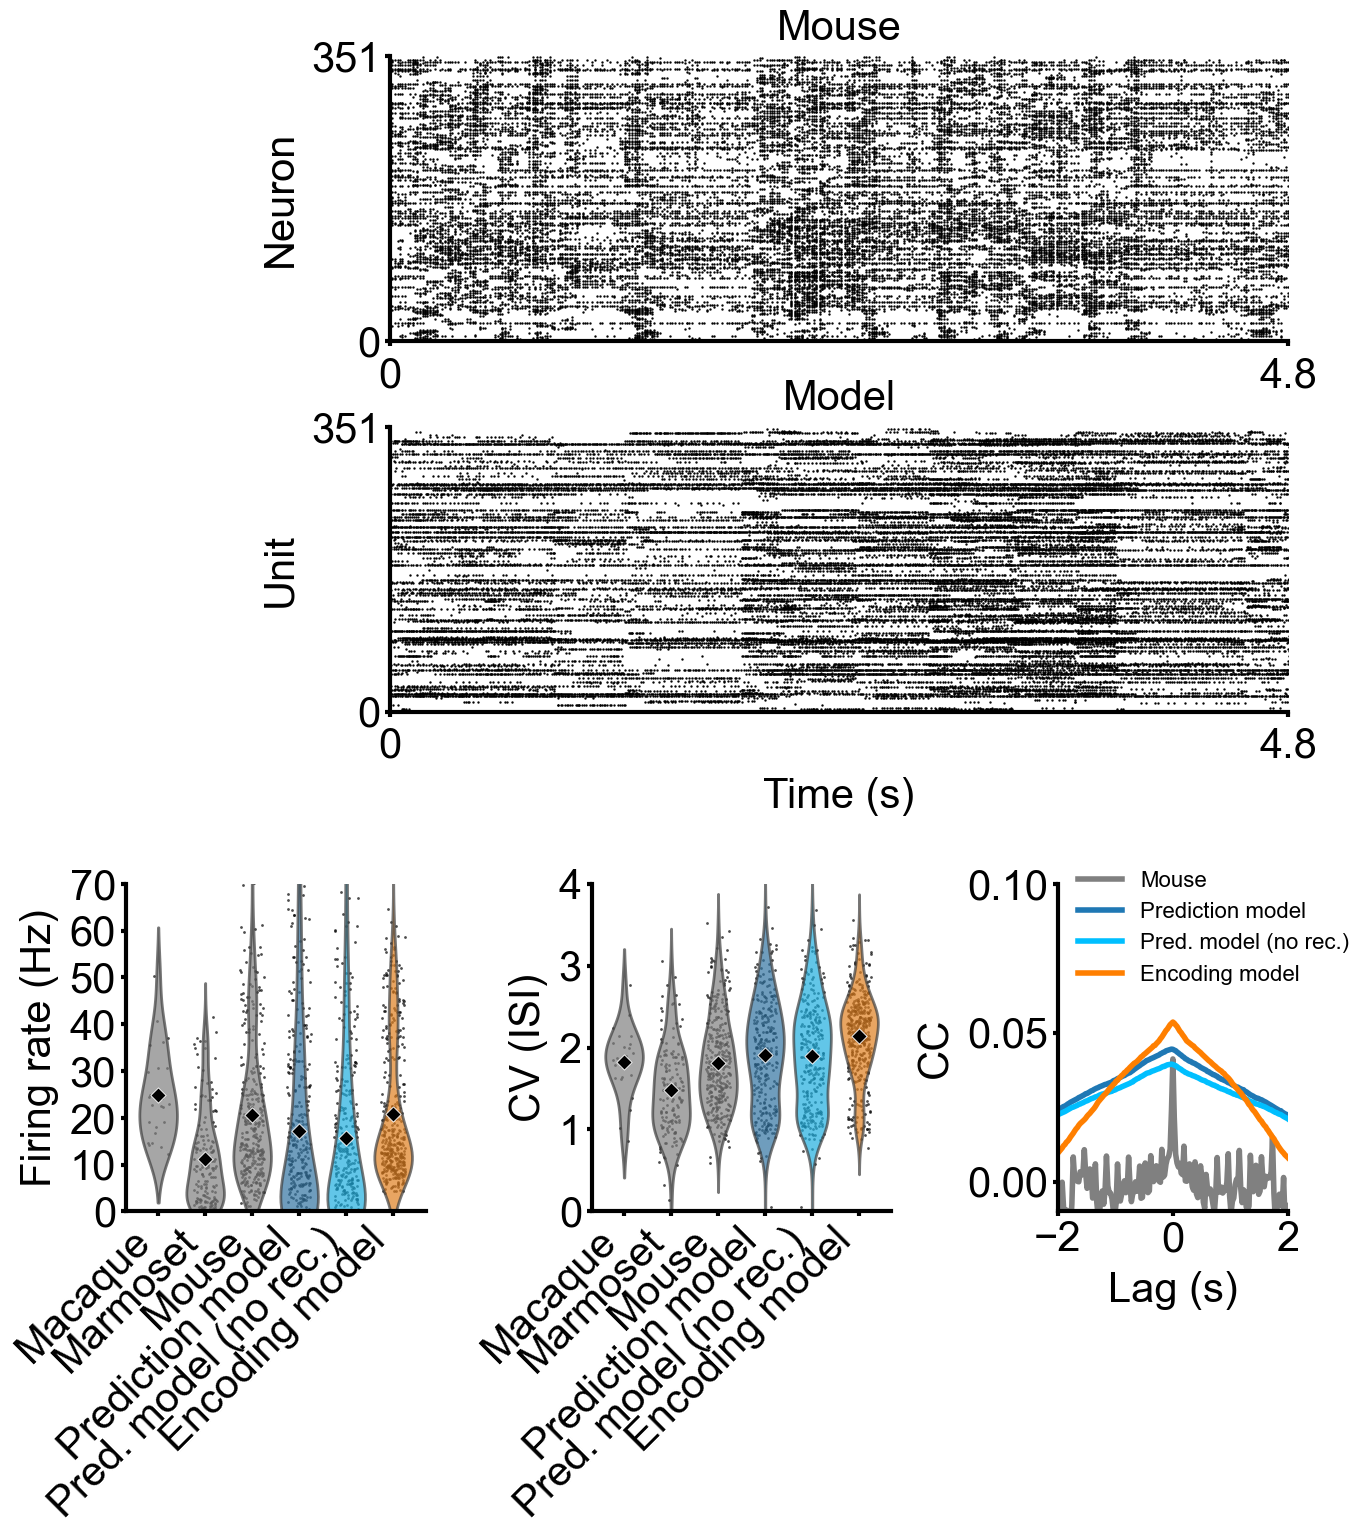

In [18]:
fig = plt.figure(figsize=(15, 15))

bottom_spec = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=fig_spec[1], width_ratios=[1.3, 1.3, 1], wspace=0.6)

# Top
ax = plt.Subplot(fig, top_spec[0])
plot_raster(*all_spike_stats.mouse_movie_stats.get_exp_spike_times(), "Mouse", 1152, "4.8", 351, "Neuron", ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, top_spec[1])
plot_raster(*all_spike_stats.mouse_movie_stats.get_pred_spike_times(active_idxs, 351, 42+10+10), "Model", 1152, "4.8", 351, "Unit", ax)
ax.set_xlabel("Time (s)", fontsize=30, labelpad=8)
fig.add_subplot(ax)

# Bottom
firing_rate_df = all_spike_stats.get_spike_rate_df(img=False)
cv_df = all_spike_stats.get_cv_df(img=False)

ax = plt.Subplot(fig, bottom_spec[0])
plot_natural_spike_stats(firing_rate_df, "Firing rate (Hz)", [0, 10, 20, 30, 40, 50, 60, 70], ["gray", "gray", "gray", dark_blue, "deepskyblue", dark_orange], ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, bottom_spec[1])
plot_natural_spike_stats(cv_df, "CV (ISI)", [0, 1, 2, 3, 4], ["gray", "gray", "gray", dark_blue, "deepskyblue", dark_orange], ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, bottom_spec[2])
plot_CC(lag_list, correlation_list, label_list, colour_list, 2, [-0.01, 0.1], ax)
leg = ax.legend(bbox_to_anchor=(1.35, 1.1), loc="upper right", fontsize=16, frameon=False)
ax.get_legend().set_title(None)
fig.add_subplot(ax)

plt.savefig(f"{root}/figures/fig2/movie_stats.svg", format="svg", transparent=False, bbox_inches="tight")

In [19]:
model_movie_firing = firing_rate_df[firing_rate_df["animal"] == "Prediction model"]["y"].values
model_movie_cvisi = cv_df[cv_df["animal"] == "Prediction model"]["y"].values

## Statistical tests

In [20]:
U1, p = mannwhitneyu(model_img_firing, model_movie_firing, alternative="less")
print(U1)
print(f"model_img_firing={model_img_firing.mean()}")
print(f"model_movie_firing={model_movie_firing.mean()}")
print(p)

62370.5
model_img_firing=8.269891255342518
model_movie_firing=17.272483934164047
2.431582613610379e-08


In [21]:
U1, p = mannwhitneyu(model_img_cvisi, model_movie_cvisi, alternative="less", nan_policy="omit")
print(U1)
print(f"model_img_firing={np.nanmean(model_img_cvisi)}")
print(f"model_movie_firing={np.nanmean(model_movie_cvisi)}")
print(p)

280.0
model_img_firing=0.38084986639751806
model_movie_firing=1.911830870408591
8.073074046195011e-93
